In [1]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def load_folds_results(base_dir, dataset_name, folds = 4):
    all_folds = {}
    for idx in range(1, folds+1):
        json_path = Path(base_dir) / f"{dataset_name}_fold{idx}_results.json"   
        with open(json_path, "r") as f:
            all_folds[idx] = json.load(f)  
    return all_folds

In [3]:
def plot_val_curves(results, fold_idx):
    runs = results["runs"]
    all_histories = {}
    for seed_name in runs:
        all_histories[seed_name] = pd.DataFrame(runs[seed_name]["history"])
    min_epochs = min(len(df) for df in all_histories.values())
    epochs = np.arange(1, min_epochs+1)
    val_loss_all= np.array([df["val_loss"].values[:min_epochs] for df in all_histories.values()])
    
    val_loss_mean = val_loss_all.mean(axis = 0)
    val_loss_std = val_loss_all.std(axis = 0)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    # LOSS
    axes[0].plot(epochs, val_loss_mean, marker="o", linewidth=2, label="Mean Validation Loss")
    axes[0].fill_between(epochs, val_loss_mean - val_loss_std, val_loss_mean + val_loss_std, alpha = 0.1, label="±1 Std")  
    axes[0].set_title(f"Fold {fold_idx} - Mean Validation Loss Across 5 Seeds", fontweight="bold")
    axes[0].set_xlabel("Epoch", fontweight="bold")
    axes[0].set_ylabel("Validation Loss", fontweight="bold")
    axes[0].set_ylim(0.0, 0.8)
    axes[0].grid(alpha = 0.3)
    axes[0].legend()
    axes[0].spines["top"].set_visible(False)
    axes[0].spines["right"].set_visible(False)

    val_acc_all = np.array([df["val_acc"].values[:min_epochs] for df in all_histories.values()])
    val_acc_mean = val_acc_all.mean(axis = 0)
    val_acc_std = val_acc_all.std(axis = 0)
    # ACC
    axes[1].plot(epochs, val_acc_mean, marker="o", linewidth=2, label="Mean Validation Accuracy")
    axes[1].fill_between(epochs, val_acc_mean - val_acc_std, val_acc_mean + val_acc_std, alpha = 0.1, label="±1 Std")
    axes[1].set_title(f"Fold {fold_idx} - Mean Validation Accuracy Across 5 Seeds", fontweight="bold")
    axes[1].set_xlabel("Epoch", fontweight="bold")
    axes[1].set_ylabel("Validation Accuracy", fontweight="bold")
    axes[1].set_ylim(0.50, 1.0)
    axes[1].grid(alpha = 0.3)
    axes[1].legend()
    axes[1].spines["top"].set_visible(False)
    axes[1].spines["right"].set_visible(False)
    
    plt.show()

In [4]:
def plot_all_folds_val_curves(all_folds):
    for idx, fold_results in all_folds.items():
        print(f"Plotting fold {idx}")
        plot_val_curves(fold_results, idx)

In [5]:
def summarize_test_results(all_folds):
    mean_f1_all = []
    mean_cm_all = []
    for idx, results in all_folds.items():
        #print(f"\n{'='*60}")
        #print(f"FOLD {idx}")
        #print(f"{'='*60}")
        
        runs = results["runs"]   
        f1_scores = []
        conf_matrices = []
        
        for seed_name, seed_data in runs.items():
            f1_scores.append(seed_data["summary"]["test_f1"])
            conf_matrices.append(np.array(seed_data["summary"]["test_conf_matrix"]))
        
        mean_f1 = np.mean(f1_scores)
        std_f1 = np.std(f1_scores)
        mean_f1_all.append(mean_f1)   
        np.set_printoptions(suppress=True, precision=2)
        mean_cm = np.mean(conf_matrices, axis = 0) 
        mean_cm_all.append(mean_cm)
        #print(f"Mean test_f1: {mean_f1:.3f} ± {std_f1:.3f}")
        #print("Mean confusion matrix:")
        #print(np.round(mean_cm, 2))
        
    overall_mean_f1 = np.mean(mean_f1_all)
    overall_std_f1 = np.std(mean_f1_all)
    overall_mean_cm = np.mean(mean_cm_all, axis=0)
    return overall_mean_f1, overall_std_f1, overall_mean_cm

## BASELINE SSL Span Algorithm Lspan 5 80/20, ENC Full FT, 1 linear FocalLoss, V3

Plotting fold 1


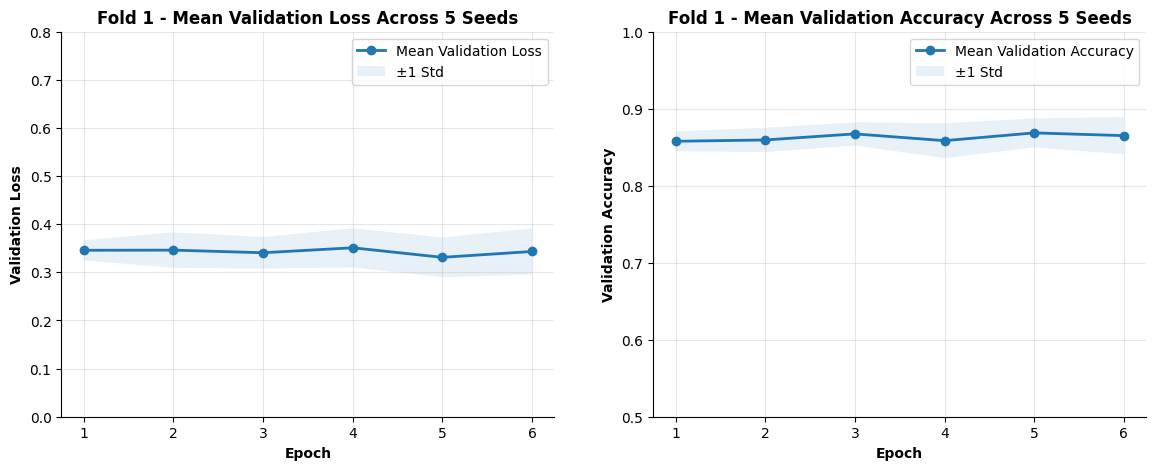

Plotting fold 2


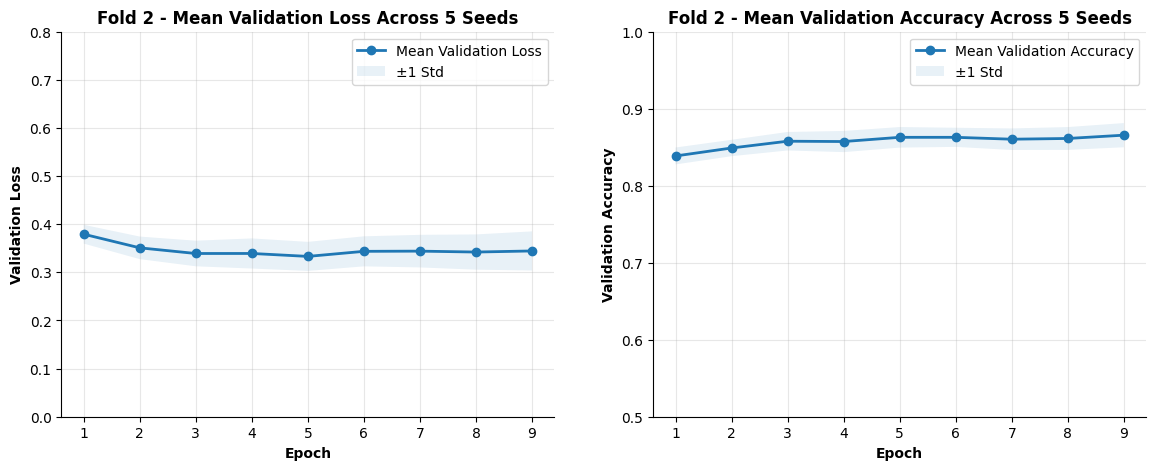

Plotting fold 3


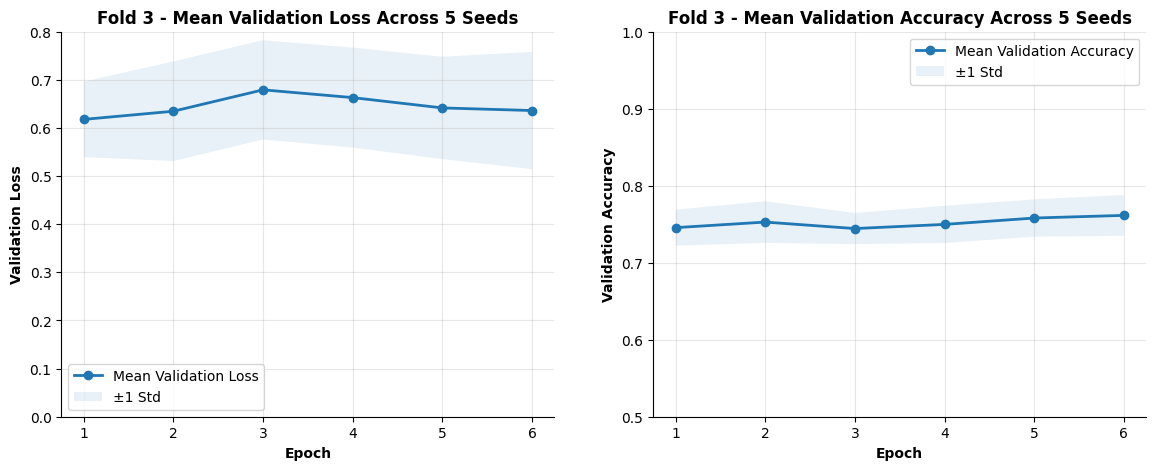

Plotting fold 4


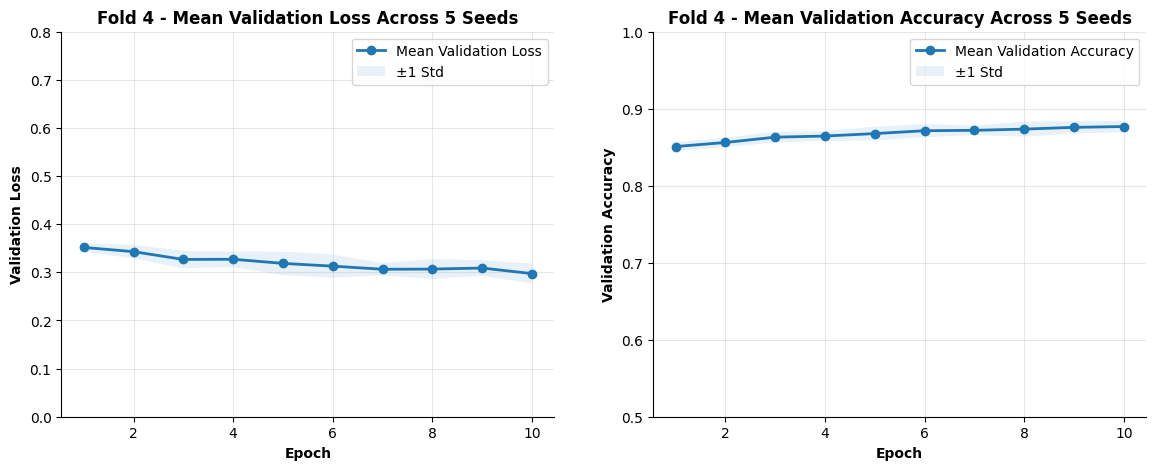

In [6]:
base_dir = "/home/kmercad/mamba_har/SELFSUPERVISED_MAMBA/results_json"
dataset_name = "OPP"

all_folds = load_folds_results(base_dir, dataset_name)
plot_all_folds_val_curves(all_folds)

In [7]:
overall_mean_f1, overall_std_f1, overall_mean_cm = summarize_test_results(all_folds)
print(f"\nOverall mean test_f1 across 4 folds: {overall_mean_f1:.4f} ± {overall_std_f1:.4f}")
print("Overall mean confusion matrix across 4 folds:")
print(np.round(overall_mean_cm, 2))


Overall mean test_f1 across 4 folds: 0.8666 ± 0.0385
Overall mean confusion matrix across 4 folds:
[[1194.4    87.7    41.5     0.65]
 [ 265.25  547.15    5.7     0.4 ]
 [  49.4     4.65  752.85    2.85]
 [   4.2     3.3     1.4   150.85]]
